In [ ]:
import os
import math
import time
import numpy as np
import pandas as pd
import itertools
from tqdm.notebook import tqdm

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.19.0


In [ ]:
from scipy.stats import gamma, beta, uniform, norm

def bsm_call_price(S, K, r, q, sigma, T):

    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    r = np.asarray(r, dtype=float)
    q = np.asarray(q, dtype=float)
    sigma = np.maximum(np.asarray(sigma, dtype=float), 1e-8)
    T = np.maximum(np.asarray(T, dtype=float), 1e-12)
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    C = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return C

# Sampling functions (as in the paper)
def thisS(q): return gamma.ppf(q, a=100, scale=1)         # Gamma(a=100, scale=1)
def thisK(q): return uniform.ppf(q, loc=50, scale=150)    # Uniform 50-200
def thisR(q): return uniform.ppf(q, loc=0.01, scale=0.17) # Uniform 0.01-0.18
def thisD(q): return uniform.ppf(q, loc=0.01, scale=0.17) # dividend same range
def thisSigma(q): return beta.ppf(q, a=2, b=5) + 0.001    # Beta(2,5) + 0.001

print("BSM and sampling functions ready.")

BSM and sampling functions ready.


In [ ]:
num_increment_full = 12
num_increment_sparse = 5
num_increment_extremes = 12

def generate_grid_df(num_increment=12, extremes=False):
    percentiles = np.linspace(0, 0.99, num_increment)
    S_vals = [thisS(q) if not extremes else uniform.ppf(q, loc=90, scale=20) for q in percentiles]
    K_vals = [thisK(q) for q in percentiles]
    q_vals = [thisD(q) for q in percentiles]
    r_vals = [thisR(q) for q in percentiles]
    sigma_vals = [thisSigma(q) for q in percentiles]
    t_vals = [0.25, 0.5, 0.75, 1.0]

    rows = []
    total_iter = (len(S_vals) * len(K_vals) * len(q_vals) * len(t_vals) * len(r_vals) * len(sigma_vals))
    print(f"Generating grid with {num_increment=} (estimated rows: {total_iter}) - extremes={extremes}")

    for S in S_vals:
        for K in K_vals:
            for q_ in q_vals:
                for t in t_vals:
                    for r_ in r_vals:
                        for sigma in sigma_vals:
                            price = bsm_call_price(S, K, r_, q_, sigma, t)
                            rows.append((S, K, q_, r_, sigma, t, price))

    df = pd.DataFrame(rows, columns=['S','K','q','r','sigma','t','price'])
    return df

# Generate datasets
t0 = time.time()
fullDF = generate_grid_df(num_increment=num_increment_full, extremes=False)
t1 = time.time()
print("Full dataset generated in {:.1f}s, shape: {}".format(t1-t0, fullDF.shape))

sparseDF = generate_grid_df(num_increment=num_increment_sparse, extremes=False)
print("Sparse shape:", sparseDF.shape)

extremesDF = generate_grid_df(num_increment=num_increment_extremes, extremes=True)
print("Extremes shape:", extremesDF.shape)

os.makedirs('/content/bs_nn_data', exist_ok=True)
fullDF.to_csv('/content/bs_nn_data/dataFull.csv', index=False)
sparseDF.to_csv('/content/bs_nn_data/dataSparse.csv', index=False)
extremesDF.to_csv('/content/bs_nn_data/dataExtremes.csv', index=False)
print("Saved CSVs to /content/bs_nn_data/")

Generating grid with num_increment=12 (estimated rows: 995328) - extremes=False


/tmp/ipython-input-1202225665.py:12: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (r - q + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)


Full dataset generated in 207.0s, shape: (995328, 7)
Generating grid with num_increment=5 (estimated rows: 12500) - extremes=False
Sparse shape: (12500, 7)
Generating grid with num_increment=12 (estimated rows: 995328) - extremes=True
Extremes shape: (995328, 7)
Saved CSVs to /content/bs_nn_data/


In [ ]:
# Creating common test set from the full datase
X_full = fullDF[['S','K','q','r','sigma','t']].values
y_full = fullDF['price'].values.ravel()
X_trainval_full, X_test_common, y_trainval_full, y_test_common = train_test_split(
    X_full, y_full, test_size=0.10, random_state=SEED
)
print("Common test set shape:", X_test_common.shape)

scaler = StandardScaler()
scaler.fit(X_trainval_full)  # fit on full training+validation portion

def prepare_Xy(df, scaler=scaler, test_fraction=0.1):
    X = df[['S','K','q','r','sigma','t']].values
    y = df['price'].values.ravel()
    X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=test_fraction, random_state=SEED)
    X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=SEED)
    # scale using provided scaler
    X_train_s = scaler.transform(X_train)
    X_val_s = scaler.transform(X_val)
    X_test_s = scaler.transform(X_test)
    return (X_train_s, y_train), (X_val_s, y_val), (X_test_s, y_test)

# Prepare for full, sparse, extremes
(train_full, y_train_full), (X_val_full, y_val_full), (X_test_full_local, y_test_full_local) = prepare_Xy(fullDF)
(train_sparse, y_train_sparse), (X_val_sparse, y_val_sparse), (X_test_sparse_local, y_test_sparse_local) = prepare_Xy(sparseDF)
(train_extreme, y_train_extreme), (X_val_extreme, y_val_extreme), (X_test_extreme_local, y_test_extreme_local) = prepare_Xy(extremesDF)

# Scale the common test set
X_test_common_scaled = scaler.transform(X_test_common)

print("Prepared scaled train/val/test sets.")


Common test set shape: (99533, 6)
Prepared scaled train/val/test sets.


In [ ]:
def build_mlp(input_dim=6, hidden_units=[200,200,200], activation='tanh', lr=1e-3):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation, kernel_initializer='glorot_uniform'))
    model.add(layers.Dense(1, activation='linear'))
    opt = optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=opt, loss='mse', metrics=['mse', 'mae'])
    return model

test_model = build_mlp()
test_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │         1,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 82,001 (320.32 KB)

 Trainable params: 82,001 (320.32 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def train_model(X_train, y_train, X_val, y_val, model_fn, model_name,
                epochs=100, batch_size=2048, checkpoint_dir='/content/bs_nn_data/models'):
    os.makedirs(checkpoint_dir, exist_ok=True)
    model = model_fn()
    ckpt_path = os.path.join(checkpoint_dir, f"{model_name}.h5")
    cb = [
        callbacks.ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True, verbose=1),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, verbose=1),
        callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)
    ]
    hist = model.fit(X_train, y_train,
                     validation_data=(X_val, y_val),
                     epochs=epochs,
                     batch_size=batch_size,
                     callbacks=cb,
                     verbose=2)
    # Save final model
    model.save(os.path.join(checkpoint_dir, f"{model_name}_final.h5"))
    return model, hist


In [ ]:
# Build model factories
model_factory = lambda: build_mlp(input_dim=6, hidden_units=[200,200,200], activation='tanh', lr=1e-3)

# Train on full dataset
print("Training on FULL dataset")
model_full, hist_full = train_model(train_full, y_train_full, X_val_full, y_val_full,
                                    model_fn=model_factory, model_name='model_full',
                                    epochs=200, batch_size=4096)

# Train on SPARSE dataset
print("Training on SPARSE dataset")
model_sparse, hist_sparse = train_model(train_sparse, y_train_sparse, X_val_sparse, y_val_sparse,
                                        model_fn=model_factory, model_name='model_sparse',
                                        epochs=200, batch_size=2048)

# Train on EXTREMES dataset
print("Training on EXTREMES dataset")
model_extreme, hist_extreme = train_model(train_extreme, y_train_extreme, X_val_extreme, y_val_extreme,
                                          model_fn=model_factory, model_name='model_extreme',
                                          epochs=200, batch_size=4096)


Training on FULL dataset
Epoch 1/200

Epoch 1: val_loss improved from inf to 55.77856, saving model to /content/bs_nn_data/models/model_full.h5


175/175 - 5s - 27ms/step - loss: 126.8296 - mae: 7.5903 - mse: 126.8296 - val_loss: 55.7786 - val_mae: 4.8389 - val_mse: 55.7786 - learning_rate: 1.0000e-03
Epoch 2/200

Epoch 2: val_loss improved from 55.77856 to 3.35183, saving model to /content/bs_nn_data/models/model_full.h5


175/175 - 1s - 4ms/step - loss: 14.9217 - mae: 1.9614 - mse: 14.9217 - val_loss: 3.3518 - val_mae: 0.8416 - val_mse: 3.3518 - learning_rate: 1.0000e-03
Epoch 3/200

Epoch 3: val_loss improved from 3.35183 to 1.31719, saving model to /content/bs_nn_data/models/model_full.h5


175/175 - 1s - 4ms/step - loss: 2.0435 - mae: 0.6433 - mse: 2.0435 - val_loss: 1.3172 - val_mae: 0.5082 - val_mse: 1.3172 - learning_rate: 1.0000e-03
Epoch 4/200

Epoch 4: val_loss improved from 1.31719 to 0.68894, saving model to /content/bs_nn_data/models/model_full.h5


175/175 - 1s - 4ms/step - loss: 0.9195 - mae: 0.4279 - mse: 0.9195 - val_loss: 0.6889 - val_mae: 0.3714 - val_mse: 0.6889 - learning_rate: 1.0000e-03
Epoch 5/200

Epoch 5: val_loss improved from 0.68894 to 0.40927, saving model to /content/bs_nn_data/models/model_full.h5


...

175/175 - 1s - 5ms/step - loss: 3.3446e-04 - mae: 0.0103 - mse: 3.3446e-04 - val_loss: 3.3078e-04 - val_mae: 0.0102 - val_mse: 3.3078e-04 - learning_rate: 1.2207e-07
Epoch 197/200

Epoch 197: val_loss improved from 0.00033 to 0.00033, saving model to /content/bs_nn_data/models/model_extreme.h5


175/175 - 1s - 5ms/step - loss: 3.3444e-04 - mae: 0.0103 - mse: 3.3444e-04 - val_loss: 3.3076e-04 - val_mae: 0.0102 - val_mse: 3.3076e-04 - learning_rate: 1.2207e-07
Epoch 198/200

Epoch 198: val_loss improved from 0.00033 to 0.00033, saving model to /content/bs_nn_data/models/model_extreme.h5


175/175 - 1s - 4ms/step - loss: 3.3442e-04 - mae: 0.0103 - mse: 3.3442e-04 - val_loss: 3.3074e-04 - val_mae: 0.0102 - val_mse: 3.3074e-04 - learning_rate: 1.2207e-07
Epoch 199/200

Epoch 199: val_loss improved from 0.00033 to 0.00033, saving model to /content/bs_nn_data/models/model_extreme.h5


175/175 - 1s - 4ms/step - loss: 3.3440e-04 - mae: 0.0103 - mse: 3.3440e-04 - val_loss: 3.3072e-04 - val_mae: 0.0102 - val_mse: 3.3072e-04 - learning_rate: 1.2207e-07
Epoch 200/200

Epoch 200: val_loss improved from 0.00033 to 0.00033, saving model to /content/bs_nn_data/models/model_extreme.h5


175/175 - 1s - 4ms/step - loss: 3.3438e-04 - mae: 0.0103 - mse: 3.3438e-04 - val_loss: 3.3070e-04 - val_mae: 0.0102 - val_mse: 3.3070e-04 - learning_rate: 1.2207e-07
Restoring model weights from the end of the best epoch: 200.


In [ ]:
def evaluate_on_common(model, X_test_common_scaled, y_test_common):
    y_pred = model.predict(X_test_common_scaled).ravel()
    mse = mean_squared_error(y_test_common, y_pred)
    mae = mean_absolute_error(y_test_common, y_pred)
    r2 = r2_score(y_test_common, y_pred)
    return {'mse': float(mse), 'mae': float(mae), 'r2': float(r2), 'y_true': y_test_common, 'y_pred': y_pred}

print("Evaluating each model on the common full test set (10% holdout from full dataset)...")
res_full = evaluate_on_common(model_full, X_test_common_scaled, y_test_common)
res_sparse = evaluate_on_common(model_sparse, X_test_common_scaled, y_test_common)
res_extreme = evaluate_on_common(model_extreme, X_test_common_scaled, y_test_common)

metrics_df = pd.DataFrame([
    {'dataset': 'full', 'mse': res_full['mse'], 'mae': res_full['mae'], 'r2': res_full['r2']},
    {'dataset': 'sparse', 'mse': res_sparse['mse'], 'mae': res_sparse['mae'], 'r2': res_sparse['r2']},
    {'dataset': 'extremes', 'mse': res_extreme['mse'], 'mae': res_extreme['mae'], 'r2': res_extreme['r2']},
])
metrics_df.to_csv('/content/bs_nn_data/metrics_on_common_test.csv', index=False)
print(metrics_df)


Evaluating each model on the common full test set (10% holdout from full dataset)...
3111/3111 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
3111/3111 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
3111/3111 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
    dataset       mse       mae        r2
0      full  0.000823  0.014947  0.999997
1    sparse  3.480795  0.984615  0.987563
2  extremes  0.368275  0.157306  0.998684


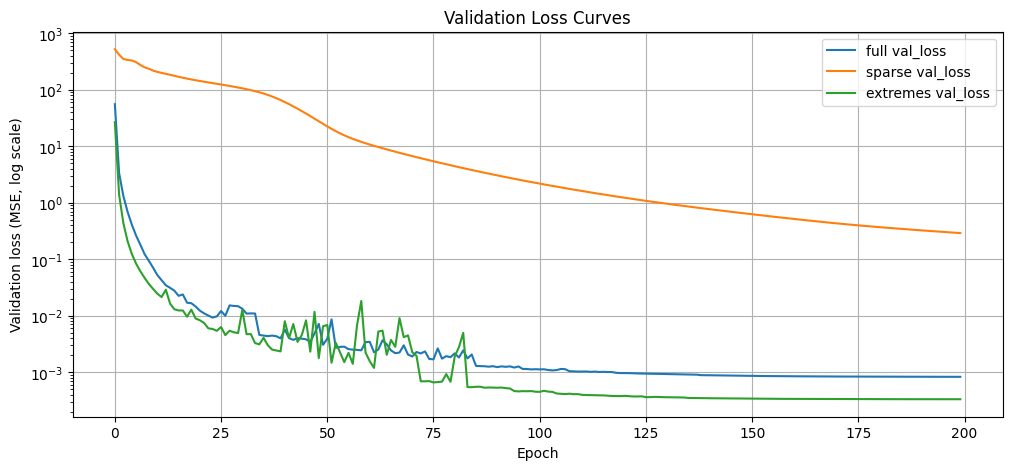

In [ ]:
import matplotlib.pyplot as plt

# Plot validation loss curves
plt.figure(figsize=(12,5))
plt.plot(hist_full.history['val_loss'], label='full val_loss')
plt.plot(hist_sparse.history['val_loss'], label='sparse val_loss')
plt.plot(hist_extreme.history['val_loss'], label='extremes val_loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Validation loss (MSE, log scale)')
plt.legend()
plt.title('Validation Loss Curves')
plt.grid(True)
plt.savefig('/content/bs_nn_data/val_loss_curves.png', dpi=150)
plt.show()

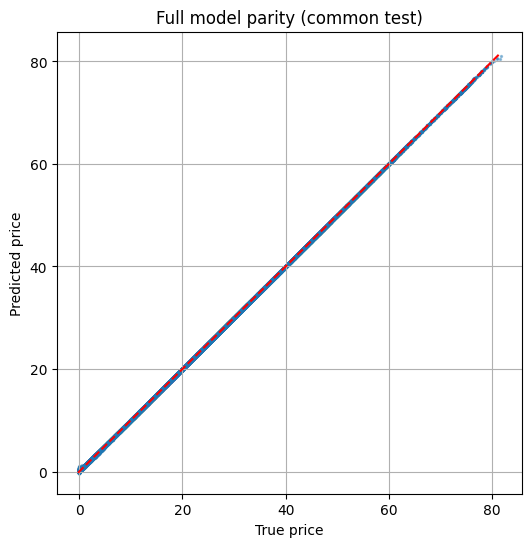

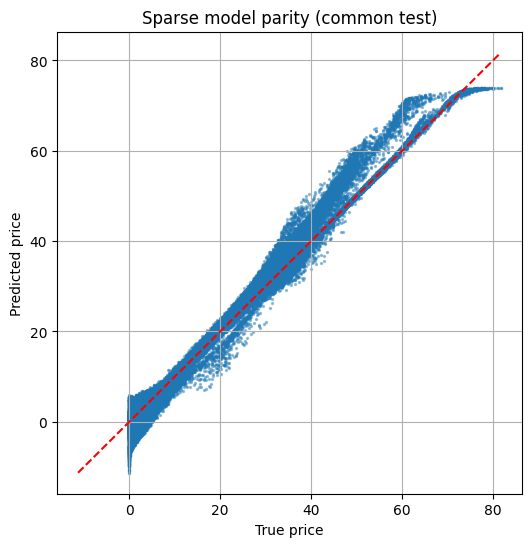

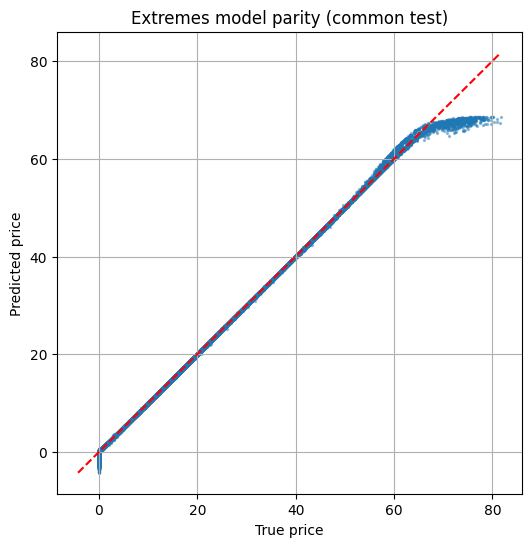

In [ ]:
# Parity plots: predicted vs true on common test set for each model
def parity_plot(y_true, y_pred, title, fname):
    """Generates and saves a parity plot."""
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, s=2, alpha=0.4)
    mn = min(y_true.min(), y_pred.min())
    mx = max(y_true.max(), y_pred.max())
    plt.plot([mn,mx], [mn,mx], 'r--')
    plt.xlabel('True price')
    plt.ylabel('Predicted price')
    plt.title(title)
    plt.grid(True)
    plt.savefig(fname, dpi=150)
    plt.show()

# Plot for the 'full' model
parity_plot(res_full['y_true'], res_full['y_pred'], 'Full model parity (common test)', '/content/bs_nn_data/parity_full.png')

# Add a visual gap in the output
print("\n\n")

# Plot for the 'sparse' model
parity_plot(res_sparse['y_true'], res_sparse['y_pred'], 'Sparse model parity (common test)', '/content/bs_nn_data/parity_sparse.png')

# Add another visual gap
print("\n\n")

# Plot for the 'extremes' model
parity_plot(res_extreme['y_true'], res_extreme['y_pred'], 'Extremes model parity (common test)', '/content/bs_nn_data/parity_extremes.png')